In [91]:
import numpy as np
print(np.__version__)


1.26.4


In [92]:
# Numerical and Data Libraries
import numpy as np
import pandas as pd
import random

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Image Processing Libraries
import cv2  # OpenCV
from PIL import Image  # Pillow

# Deep Learning Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.datasets import mnist
from sklearn.metrics import confusion_matrix  # More flexible

# Reproducibility
np.random.seed(3)
random.seed(3)
tf.random.set_seed(3)


#### Loading the pre processed image from (MNISt)

In [93]:
(X_train, Y_train), (X_test, Y_test) = mnist.load_data()

In [94]:
type(X_train)

numpy.ndarray

In [95]:
print(X_train.shape, Y_train.shape, X_test.shape, Y_test.shape)

(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


* 60,000 Gray scale images for training purpose, with dimension of (height = 28, width =28)
* Label as number image in Y_train.
* Gray scale image has only one color channel. 

#### Print the one image of X_train (11 th image) 


In [96]:
print(X_train[10])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0  42 118 219 166 118 118   6
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 103 242 254 254 254 254 254  66
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0  18 232 254 254 254 254 254 238
   70   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0 104 244 254 224 254 254 254
  141   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0 207 254 210 25

In [97]:
print(X_train[10].shape)

(28, 28)


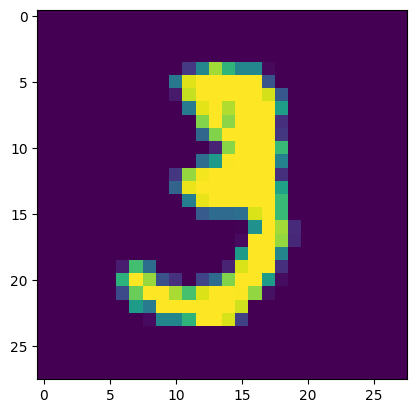

In [98]:
# Display this image: 
plt.imshow(X_train[10])
plt.show()

In [99]:
# Printing the corresponding label 
Y_train[10]

3

#### Image labels

In [100]:
print(Y_train.shape, Y_test.shape)

(60000,) (10000,)


In [101]:
# Unique Values in this labels
print(np.unique(Y_train))
print(np.unique(Y_test))

[0 1 2 3 4 5 6 7 8 9]
[0 1 2 3 4 5 6 7 8 9]


* We can use this labels as it is or we can also apply One hot encoding
* In onhot encoding
* [1,0....], [0,1,0...].... for all labels.

* All the images have thesame dimension.
* If not we have to resize all imges to a common dimension. 

#### Scaling the values  from 0 to 255 to 0 to 1 
* this is called normalization.

In [102]:
X_train = X_train/255
X_test = X_test/255

In [103]:
print(X_train[10])

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.    

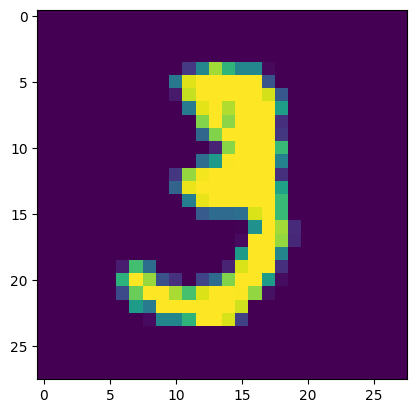

In [104]:
plt.imshow(X_train[10])

### Building the Neural Network:

* CNN (efficient for image data)
* RNN (efficient for Text/Audio data)
* In this notebook (Basic neural networ is used)

In [105]:
# Setting up the layers :
model = keras.Sequential([
    keras.layers.Flatten(input_shape = (28,28)),
    keras.layers.Dense(50, activation= 'relu'), 
    keras.layers.Dense(50, activation= 'relu'), 
    keras.layers.Dense(10, activation= 'sigmoid')  # 10 -- Since we have 10 output label class. 
  
])

/home/saji/anaconda3/lib/python3.9/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [106]:
# Compiling the model
model.compile(
    optimizer="adam",  # Optimizer: adjusts the weights to minimize the loss function (Adam is adaptive and efficient).
    loss="sparse_categorical_crossentropy",  # Loss function: used for multi-class classification when labels are integers (e.g., 0, 1, 2, …).
    metrics=["accuracy"]  # Metric: measures performance; accuracy = correct predictions / total predictions.
)


In [107]:
# Training the neural network:
history = model.fit(X_train, Y_train, epochs = 10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8519 - loss: 0.5179
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9575 - loss: 0.1445
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9692 - loss: 0.1031
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9757 - loss: 0.0812
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9793 - loss: 0.0664
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9820 - loss: 0.0559
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9850 - loss: 0.0477
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9876 - loss: 0.0404
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9888 - loss: 0.0364
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9894 - loss: 0.0318


* This accuracy says for out of 100 data for 98 data it predicts correctly.
* Here training data accurac is 98.92%

##### ModelEvaluation

In [108]:
# Checking accuracy of the model on test data :
loss, accuracy = model.evaluate(X_test,Y_test)
print(accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9623 - loss: 0.1362
0.967199981212616


* Test data accuracy is 96.12
* Hence it didnt do over fitting.

In [109]:
print(X_test.shape)

(10000, 28, 28)


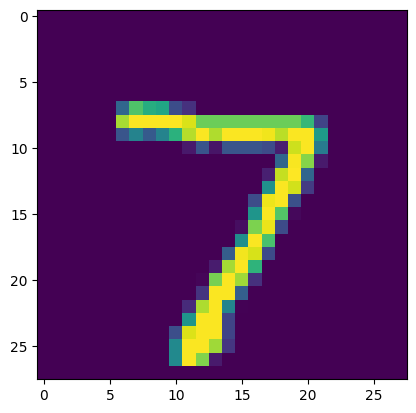

In [110]:
plt.imshow(X_test[0])
plt.show()

In [111]:
print(Y_test[0])

7


####  Check for individual image:

In [112]:
Y_pred = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [113]:
Y_pred.shape

(10000, 10)

In [114]:
print(Y_pred[0])

[3.8550276e-04 1.1191121e-07 1.2245600e-02 9.1545171e-01 1.4531635e-08
 5.7674635e-05 2.3767441e-09 9.9999952e-01 9.1218516e-02 5.5852735e-01]


* model.predict() : It will give the probability of individual labels/class 0,1,2,3,...9 for the particular image. 

In [115]:
# Converting the prediction probability to class labels:
label_for_image_1 = np.argmax(Y_pred[0])
print(label_for_image_1)

7


In [116]:
# Converting the prediction prob in to label  for all image on test

In [117]:
# Y_pred_labels --> predicted by NN
Y_pred_label = [np.argmax(i)  for i in Y_pred]
print(Y_pred_label)

[7, 2, 1, 0, 4, 1, 4, 9, 5, 9, 0, 6, 9, 0, 1, 5, 9, 7, 8, 4, 9, 6, 6, 5, 4, 0, 7, 4, 0, 1, 3, 1, 3, 4, 7, 2, 7, 1, 2, 1, 1, 7, 4, 2, 3, 5, 1, 2, 4, 4, 6, 3, 5, 5, 6, 0, 4, 1, 9, 5, 7, 8, 9, 3, 7, 4, 6, 4, 3, 0, 7, 0, 2, 9, 1, 7, 3, 2, 9, 7, 7, 6, 2, 7, 8, 4, 7, 3, 6, 1, 3, 6, 4, 3, 1, 4, 1, 7, 6, 9, 6, 0, 5, 4, 9, 9, 2, 1, 9, 4, 8, 7, 3, 9, 7, 4, 4, 4, 9, 2, 5, 4, 7, 6, 7, 9, 0, 5, 8, 5, 6, 6, 5, 7, 8, 1, 0, 1, 6, 4, 6, 7, 3, 1, 7, 1, 8, 2, 0, 2, 9, 8, 5, 5, 1, 5, 6, 0, 3, 4, 4, 6, 5, 4, 6, 5, 4, 5, 1, 4, 4, 7, 2, 3, 2, 7, 1, 8, 1, 8, 1, 8, 5, 0, 8, 9, 2, 5, 0, 1, 1, 1, 0, 8, 0, 5, 1, 6, 4, 2, 3, 6, 1, 1, 1, 3, 9, 5, 2, 9, 4, 5, 9, 3, 9, 0, 3, 6, 5, 5, 7, 2, 2, 7, 1, 2, 8, 4, 1, 7, 3, 3, 8, 8, 7, 9, 2, 2, 4, 1, 5, 9, 8, 7, 2, 3, 0, 2, 4, 2, 4, 1, 9, 5, 7, 7, 2, 8, 2, 0, 8, 5, 7, 7, 4, 1, 8, 1, 8, 0, 3, 0, 1, 9, 3, 4, 1, 8, 2, 1, 2, 9, 7, 5, 9, 2, 6, 4, 1, 5, 8, 2, 9, 2, 0, 4, 0, 0, 2, 8, 4, 7, 1, 2, 4, 0, 2, 7, 4, 3, 3, 0, 0, 3, 1, 9, 6, 5, 2, 5, 9, 7, 9, 3, 0, 4, 2, 0, 7, 1, 1, 2, 1, 

In [118]:
#print(Y_pred)

#### Confusion matrix

In [119]:
conf_mat = confusion_matrix(Y_test, Y_pred_label)
print(conf_mat) 


[[ 964    0    1    3    2    2    3    1    1    3]
 [   0 1112    3    4    1    1    5    2    7    0]
 [   8    1  985   17    3    0    6    3    9    0]
 [   1    0   10  973    0    7    1    4    4   10]
 [   1    0    3    0  969    1    5    0    1    2]
 [   2    0    1   14    3  853   11    1    5    2]
 [   8    2    2    0    8    1  935    0    2    0]
 [   3    1   11    5    6    0    1  983    3   15]
 [   3    0    2    9    5    7    2    0  944    2]
 [   1    2    0    6   27    5    1    3   10  954]]


Text(158.22222222222223, 0.5, 'True label')

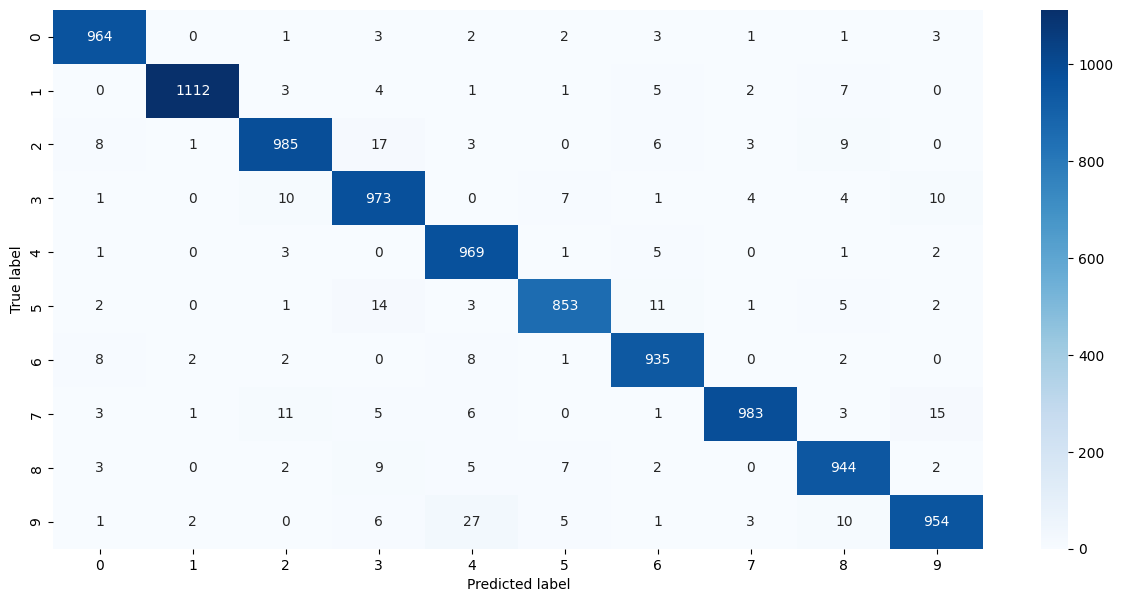

In [120]:
plt.figure(figsize=(15,7))
sns.heatmap(conf_mat, annot = True, fmt = 'd', cmap = "Blues") # fmt = "d" --> integers
plt.xlabel("Predicted label")
plt.ylabel("True label")

* What this confusion matrix says:
* element 0,0 : there are 950 images whose true value is 0 and model also predicted as 0.(or: 950 --0 labels images are correctly predicted as 0, 975 --9 label image are correctly predicted as 9)
* Lets take third element in first row:  there is one image whose tru value is 2 but model predicted as 0




### Confusion Matrix Explanation

* row usually : true values and 
* col usually as : predicted values.

* **Element (0,0):** There are **950 images** whose true label is `0` and the model also predicted them as `0`.  
* **Example - Element (0,2):** There is **1 image** whose true label is `2`, but the model incorrectly predicted it as `0`.  


###  Build a predictive images: (but we should give MNISt type data/image)

In [121]:
input_image_path = "sample_image.png"
input_image = cv2.imread(input_image_path)
type(input_image)

numpy.ndarray

In [122]:
#print(input_image)

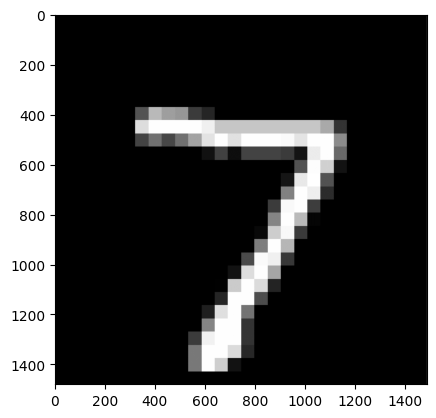

In [123]:
plt.imshow(input_image)

In [140]:
input_image.shape

(1480, 1490, 3)

* it is an Rgb, we need to convert it into Gray scale image with pixel(28,28). 

In [143]:
# Converting into gray scale :
grayscale = cv2.cvtColor(input_image, cv2.COLOR_RGB2GRAY)

In [144]:
grayscale.shape

(1480, 1490)

In [145]:
# Resize the image
input_image_resize = cv2.resize(grayscale, (28,28))

In [146]:
input_image_resize.shape

(28, 28)

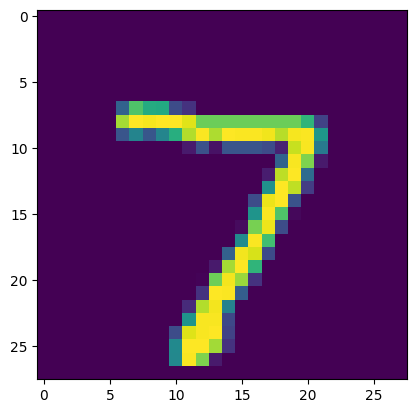

In [147]:
plt.imshow(input_image_resize)
plt.show()

In [148]:
# Scaling (Normalization)
input_image_resize = input_image_resize/255
print(input_image_resize)

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.    

In [149]:
image_reshaped = np.reshape(input_image_resize, [1,28,28])  # to tell the NN model that iam going to give the data for 1 image and predict for this one image. 

In [150]:
input_pred = model.predict(image_reshaped)
print(input_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
[[3.7645863e-04 1.2162303e-07 1.3064609e-02 9.1534209e-01 1.4361459e-08
  5.7405872e-05 2.5125697e-09 9.9999958e-01 8.8128373e-02 5.4465866e-01]]


In [152]:
inp_pred_label = np.argmax(input_pred)
print(inp_pred_label)

7


In [153]:
print("The Handwritten letter is : ", inp_pred_label)

The Handwritten letter is :  7
